In [ ]:
!pip install gdown

In [ ]:
import gdown

url = 'https://drive.google.com/uc?id=1wPDyOb8xNME6808XJ1aCNBPB35CcHu2I'
output = 'creditcard.csv'

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1wPDyOb8xNME6808XJ1aCNBPB35CcHu2I
From (redirected): https://drive.google.com/uc?id=1wPDyOb8xNME6808XJ1aCNBPB35CcHu2I&confirm=t&uuid=f2c4c030-472c-4153-983f-8d008eec1694
To: /content/creditcard.csv
100%|██████████| 151M/151M [00:02<00:00, 62.1MB/s]


'creditcard.csv'

In [ ]:
import pandas as pd

df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.shape

(284807, 31)

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


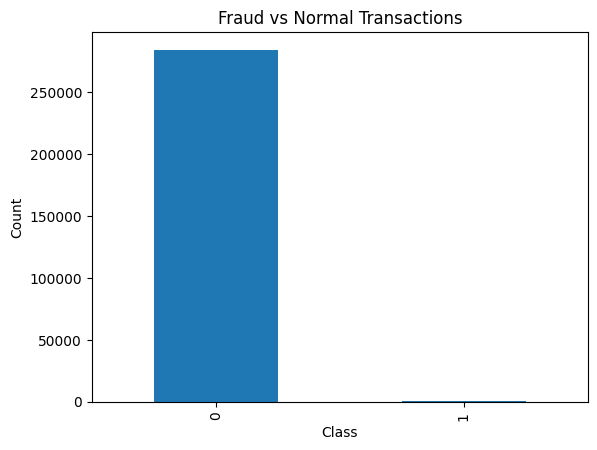

In [ ]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title('Fraud vs Normal Transactions')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

## Step 1 (continued): Additional Preprocessing Steps
### Rama Bani Younis

In [ ]:
# ---- Preprocessing Step 4: Outlier Removal using IQR ----
print('Shape before outlier removal:', X.shape)

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

# Keep rows within 3*IQR range (conservative to preserve fraud cases)
mask = ~((X < (Q1 - 3 * IQR)) | (X > (Q3 + 3 * IQR))).any(axis=1)
X = X[mask]
y = y[mask]

print('Shape after outlier removal:', X.shape)
print(f'Removed {(~mask).sum()} outlier rows')

In [ ]:
# ---- Preprocessing Step 5: PCA - Dimensionality Reduction ----
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Apply PCA to see how much variance each component explains
pca_full = PCA(random_state=42)
pca_full.fit(X)

# Plot explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', markersize=3, color='steelblue')
plt.axhline(y=95, color='red', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 95) + 1
print(f'Components needed for 95% variance: {n_components_95}')

In [ ]:
# ---- PCA 2D Visualization (Feature Space) ----
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(10, 6))
colors = {0: 'steelblue', 1: 'red'}
labels = {0: 'Normal', 1: 'Fraud'}

for cls in [0, 1]:
    mask_cls = (y == cls).values
    plt.scatter(X_pca_2d[mask_cls, 0], X_pca_2d[mask_cls, 1],
                c=colors[cls], label=labels[cls],
                alpha=0.4, s=5)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA 2D Projection - Normal vs Fraud Transactions')
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig('pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2: SMOTE + Model Training
### Yara Dghaim

In [ ]:
# Install imbalanced-learn if needed
!pip install imbalanced-learn -q

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split BEFORE applying SMOTE (important!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Before SMOTE:')
print('Training set class distribution:')
print(y_train.value_counts())

In [ ]:
# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('After SMOTE:')
print('Training set class distribution:')
import pandas as pd
print(pd.Series(y_train_res).value_counts())

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_res, y_train_res)

print('Models trained successfully!')

In [ ]:
# Generate predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

print('Predictions generated for both models.')

## Step 3: Evaluation + Visualization
### Sara Jaradat

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---- Metrics Function ----
def evaluate_model(name, y_true, y_pred):
    print(f'\n========== {name} ==========')
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'Recall   : {recall_score(y_true, y_pred):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred):.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))

evaluate_model('Logistic Regression', y_test, y_pred_lr)
evaluate_model('Decision Tree', y_test, y_pred_dt)

In [ ]:
# ---- Confusion Matrices (Heatmaps) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree', y_pred_dt),
]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'])
    ax.set_title(f'Confusion Matrix - {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ---- Metrics Comparison Bar Chart ----
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

lr_scores = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr),
]

dt_scores = [
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt),
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x + width/2, dt_scores, width, label='Decision Tree', color='coral')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Logistic Regression vs Decision Tree', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ---- Conclusion ----
lr_f1 = f1_score(y_test, y_pred_lr)
dt_f1 = f1_score(y_test, y_pred_dt)

print('===== CONCLUSION =====')
print(f'Logistic Regression F1-Score: {lr_f1:.4f}')
print(f'Decision Tree       F1-Score: {dt_f1:.4f}')

if lr_f1 > dt_f1:
    print('\n>>> Best Model: Logistic Regression')
    print('Reason: Higher F1-Score means better balance between Precision and Recall,')
    print('which is critical in fraud detection where missing fraud (False Negatives) is costly.')
else:
    print('\n>>> Best Model: Decision Tree')
    print('Reason: Higher F1-Score means better balance between Precision and Recall,')
    print('which is critical in fraud detection where missing fraud (False Negatives) is costly.')